In [ ]:
!pip -q install -U diffusers transformers datasets peft pillow scipy

# Мини проект ВК: **Генеративная модель для создания изображений**


**Задание:**
1) Соберите и обработайте данные (тексты и изображения).

2) Разработайте (обучите) модель, используя методы трансферного обучения и генеративные модели (например, GAN).

3) Попробуйте запустить модель, оцените качество результатов с помощью конкретных метрик (например, IS).

4) Создайте веб-интерфейс для демонстрации результатов.

Была сформулирована следующа цель:

**Цель:**

Обучить LoRA-адаптер для генерации мультяшных аватаров лиц на основе текстового описания атрибутов изображения.

**Ход решения:**
1) Взяты данные с hf, содержащие изображения анимационных лиц (аватаров) с автоматическим описанием.

2) В качестве модели была выбрана SD 1.5, тк она не требовательная по памяти (в сравнении с другими диффузиями) и хорошо подходит для учебных задач.

3) Через peft была добавлена Lora на слои атешена, для обучения модели стилю по созданию мультяшных изображений.

4) Лора была обучена на 1000 шагах с батчем 4, чего хватило для задания целевого стиля генерации изображений.

5) Были сняты сравнительные метрики на базовой модели и с добавлением лоры:
   
   а) CLIP(prompt&image) - семантическое соответсвие изображения промпту

   б) Image similarity (original&generated) - clip соответствие генерации оригинальному изображению

   в) CLIP std per prompt - разброс clip эмбединга на изображении генерации на разных сидах внутри одного промта

   г) Intra-prompt similarity - clip схожесть генераций на разных сидах внутри одного промпта

6) Для визуализации был поднят вебинтерфейс на gradio для запуска базовой модели и модели с лорой.

**Дополнительно:**

Также рассматривалась задача по генерации графиков и номерных пластин ГРЗ с обучением лоры для SD 1.5 + Controlnet. Однако код обучения, веса и преподготовленные данные были стерты. Результат данных экспериментов представлен в презентации в виде сохранившихся артефактов валидации.

In [ ]:
import os
import gc
import math
import random
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import defaultdict
import itertools

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from transformers import CLIPProcessor, CLIPModel

from datasets import load_dataset
from transformers import CLIPTokenizer, CLIPTextModel
from transformers import CLIPProcessor, CLIPModel
from diffusers import AutoencoderKL, UNet2DConditionModel, DDPMScheduler
from peft import LoraConfig
from peft.utils import get_peft_model_state_dict
from diffusers.utils import convert_state_dict_to_diffusers
from diffusers.loaders import StableDiffusionLoraLoaderMixin

In [ ]:
SEED = 42
MODEL_NAME = "runwayml/stable-diffusion-v1-5"
DATASET_NAME = "Skiittoo/cartoon-faces"

OUTPUT_DIR = Path("/content/manual_lora_safe")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

IMAGE_SIZE = 256
BATCH_SIZE = 4
NUM_WORKERS = 2
MAX_TRAIN_STEPS = 1000
LEARNING_RATE = 5e-5
LORA_RANK = 8
MAX_GRAD_NORM = 1.0
SAVE_EVERY = 250

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE

'cuda'

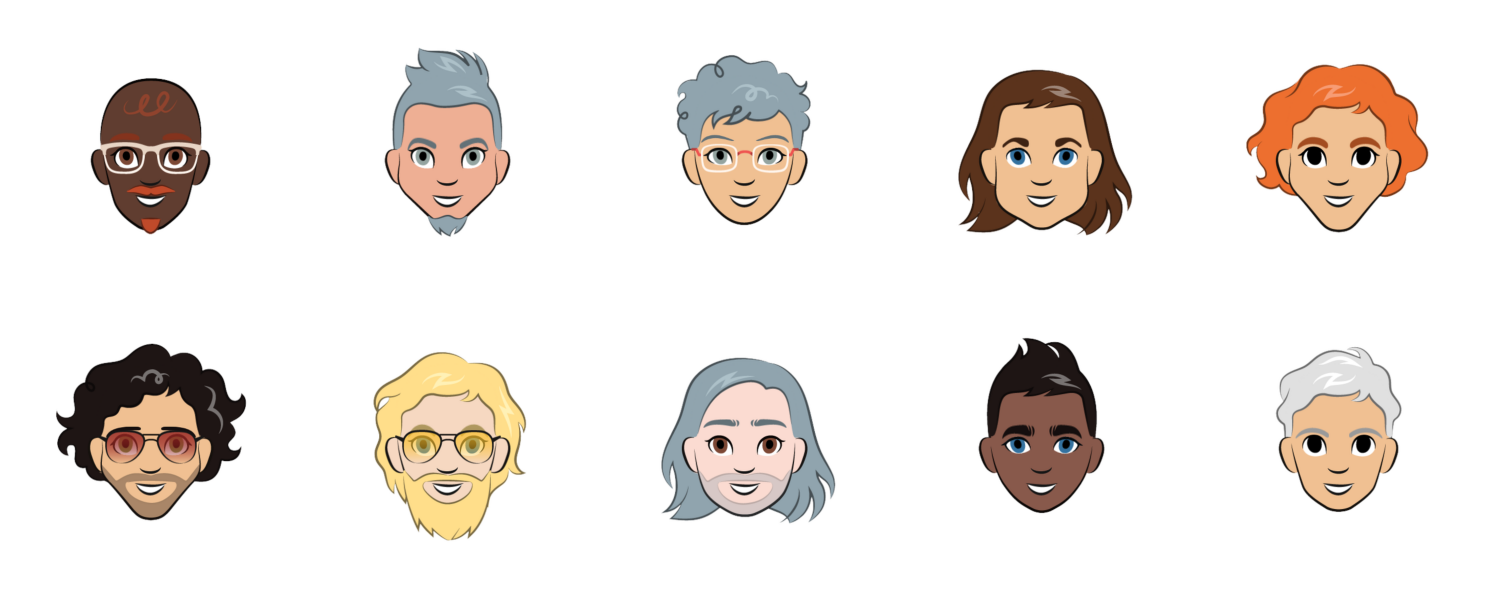

In [ ]:
NUM_SAMPLES = 10

indices = random.sample(range(len(hf_ds)), NUM_SAMPLES)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, idx in zip(axes.flatten(), indices):

    img = hf_ds[idx]["image"]
    prompt = hf_ds[idx]["text"]

    ax.imshow(img)
    # ax.set_title(prompt, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
class CartoonFacesDataset(Dataset):
    def __init__(self, hf_dataset, transform):
        self.ds = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        sample = self.ds[idx]
        image = sample["image"]
        if image.mode != "RGB":
            image = image.convert("RGB")
        image = self.transform(image)
        caption = sample["text"]
        return {"pixel_values": image, "caption": caption}

def collate_fn(batch):
    pixel_values = torch.stack([x["pixel_values"] for x in batch])
    captions = [x["caption"] for x in batch]
    return {"pixel_values": pixel_values, "captions": captions}

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

hf_ds = load_dataset(DATASET_NAME, split="train")
train_dataset = CartoonFacesDataset(hf_ds, train_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    collate_fn=collate_fn,
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/485 [00:00<?, ?B/s]

data/train-00000-of-00002-8ba8487e6dfe65(…):   0%|          | 0.00/324M [00:00<?, ?B/s]

data/train-00001-of-00002-3cc34232d9bab2(…):   0%|          | 0.00/324M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [ ]:
def count_trainable_params(model):
    total = 0
    trainable = 0
    for p in model.parameters():
        total += p.numel()
        if p.requires_grad:
            trainable += p.numel()
    print(f"Trainable params: {trainable:,}")
    print(f"Total params:     {total:,}")
    print(f"Trainable %:      {100 * trainable / total:.4f}%")


tokenizer = CLIPTokenizer.from_pretrained(MODEL_NAME, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(MODEL_NAME, subfolder="text_encoder")
vae = AutoencoderKL.from_pretrained(MODEL_NAME, subfolder="vae")
unet = UNet2DConditionModel.from_pretrained(MODEL_NAME, subfolder="unet")
noise_scheduler = DDPMScheduler.from_pretrained(MODEL_NAME, subfolder="scheduler")

text_encoder.to(DEVICE, dtype=torch.float32)
vae.to(DEVICE, dtype=torch.float32)
unet.to(DEVICE, dtype=torch.float32)

text_encoder.requires_grad_(False)
vae.requires_grad_(False)
unet.requires_grad_(False)

lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_RANK,
    init_lora_weights="gaussian",
    target_modules=["to_k", "to_q", "to_v", "to_out.0"],
)

unet.add_adapter(lora_config, adapter_name="my_lora")
unet.set_adapter("my_lora")
count_trainable_params(unet)

tokenizer_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

...

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

Trainable params: 1,594,368
Total params:     861,115,332
Trainable %:      0.1852%


In [ ]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, unet.parameters()),
    lr=LEARNING_RATE,
    betas=(0.9, 0.999),
    weight_decay=1e-2,
    eps=1e-8,
)

In [ ]:
unet.train()
text_encoder.eval()
vae.eval()

global_step = 0
loss_history = []
skipped_batches = 0

pbar = tqdm(total=MAX_TRAIN_STEPS, desc="training", dynamic_ncols=True)

while global_step < MAX_TRAIN_STEPS:
    for batch in train_loader:
        if global_step >= MAX_TRAIN_STEPS:
            break

        pixel_values = batch["pixel_values"].to(DEVICE, dtype=torch.float32, non_blocking=True)

        with torch.no_grad():
            latents = vae.encode(pixel_values).latent_dist.sample()
            latents = latents * vae.config.scaling_factor

            noise = torch.randn_like(latents)
            bsz = latents.shape[0]
            timesteps = torch.randint(
                0,
                noise_scheduler.config.num_train_timesteps,
                (bsz,),
                device=latents.device,
                dtype=torch.long,
            )

            text_inputs = tokenizer(
                batch["captions"],
                padding="max_length",
                truncation=True,
                max_length=tokenizer.model_max_length,
                return_tensors="pt",
            )
            input_ids = text_inputs.input_ids.to(DEVICE)
            encoder_hidden_states = text_encoder(input_ids)[0]

        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        noise_pred = unet(
            noisy_latents,
            timesteps,
            encoder_hidden_states=encoder_hidden_states,
        ).sample


        loss = F.mse_loss(noise_pred.float(), noise.float(), reduction="mean")

        if not torch.isfinite(loss):
            skipped_batches += 1
            optimizer.zero_grad(set_to_none=True)
            continue

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(unet.parameters(), MAX_GRAD_NORM)
        optimizer.step()

        global_step += 1
        loss_history.append(loss.item())

        mean_loss = np.mean(loss_history[-20:])

        pbar.set_postfix(
            step=global_step,
            loss=f"{mean_loss:.4f}",
            skipped=skipped_batches
        )

        pbar.update(1)

        if global_step % SAVE_EVERY == 0:
            save_dir = OUTPUT_DIR / f"checkpoint-{global_step}"
            save_dir.mkdir(parents=True, exist_ok=True)
            unet_lora_state_dict = convert_state_dict_to_diffusers(
                get_peft_model_state_dict(unet, adapter_name='my_lora')
            )
            StableDiffusionLoraLoaderMixin.save_lora_weights(
                save_directory=str(save_dir),
                unet_lora_layers=unet_lora_state_dict,
                safe_serialization=True,
            )


final_dir = OUTPUT_DIR / "final"
final_dir.mkdir(parents=True, exist_ok=True)

unet_lora_state_dict = convert_state_dict_to_diffusers(
    get_peft_model_state_dict(unet, adapter_name='my_lora')
)

StableDiffusionLoraLoaderMixin.save_lora_weights(
    save_directory=str(final_dir),
    unet_lora_layers=unet_lora_state_dict,
    safe_serialization=True,
)

training: 100%|██████████| 1000/1000 [05:17<00:00,  3.17it/s, loss=0.0340, skipped=0, step=1000]

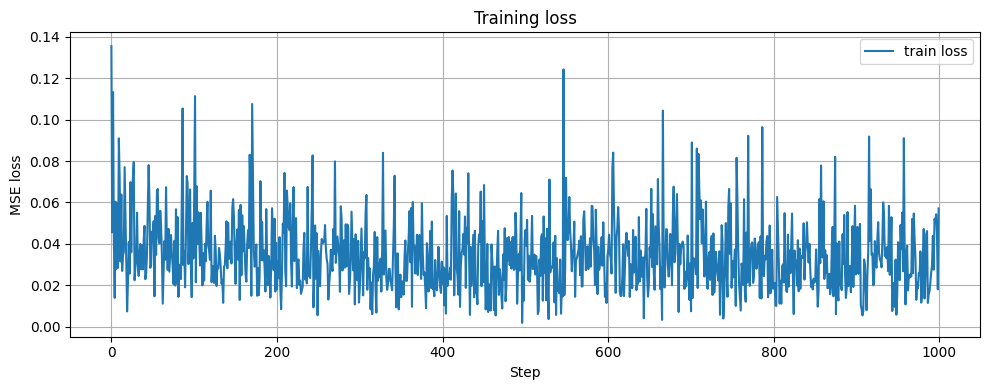

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(loss_history, label="train loss")
plt.xlabel("Step")
plt.ylabel("MSE loss")
plt.title("Training loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
indices = random.sample(range(len(hf_ds)), 10)
prompts = [hf_ds[i]["text"] for i in indices]


for i, p in enumerate(prompts, 1):
    print(f"{i}. {p}")

1. Cartoon face with glasses, without facial hair, white hair and with brown skin
2. Cartoon face with glasses, with facial hair, orange hair and with white skin
3. Cartoon face with glasses, without facial hair, yellow hair and with yellow skin
4. Cartoon face with glasses, with facial hair, yellow hair and with dark skin
5. Cartoon face with glasses, without facial hair, orange hair and with white skin
6. Cartoon face with glasses, without facial hair, white hair and with brown skin
7. Cartoon face with glasses, without facial hair, whitish-yellow hair and with dark skin
8. Cartoon face without glasses, without facial hair, dark-orange hair and with white skin
9. Cartoon face with glasses, without facial hair, yellow hair and with white skin
10. Cartoon face without glasses, with facial hair, yellow hair and with yellow skin


In [ ]:
from diffusers import StableDiffusionPipeline

final_dir = OUTPUT_DIR / "final"
final_dir.mkdir(parents=True, exist_ok=True)

pipe_base = StableDiffusionPipeline.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    safety_checker=None,
    requires_safety_checker=False,
).to(DEVICE)
pipe_base.set_progress_bar_config(disable=True)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
pipe_lora = StableDiffusionPipeline.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    safety_checker=None,
    requires_safety_checker=False,
).to(DEVICE)
pipe_lora.set_progress_bar_config(disable=True)

pipe_lora.load_lora_weights(
    str(final_dir),
    weight_name="pytorch_lora_weights.safetensors",
)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new



100%|██████████| 10/10 [00:14<00:00,  1.46s/it]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]


 10%|█         | 1/10 [00:01<00:14,  1.60s/it]

  0%|          | 0/20 [00:00<?, ?it/s]


 20%|██        | 2/10 [00:03<00:12,  1.60s/it]

...


 80%|████████  | 8/10 [00:12<00:03,  1.61s/it]

  0%|          | 0/20 [00:00<?, ?it/s]


 90%|█████████ | 9/10 [00:14<00:01,  1.61s/it]

  0%|          | 0/20 [00:00<?, ?it/s]


100%|██████████| 10/10 [00:16<00:00,  1.61s/it]


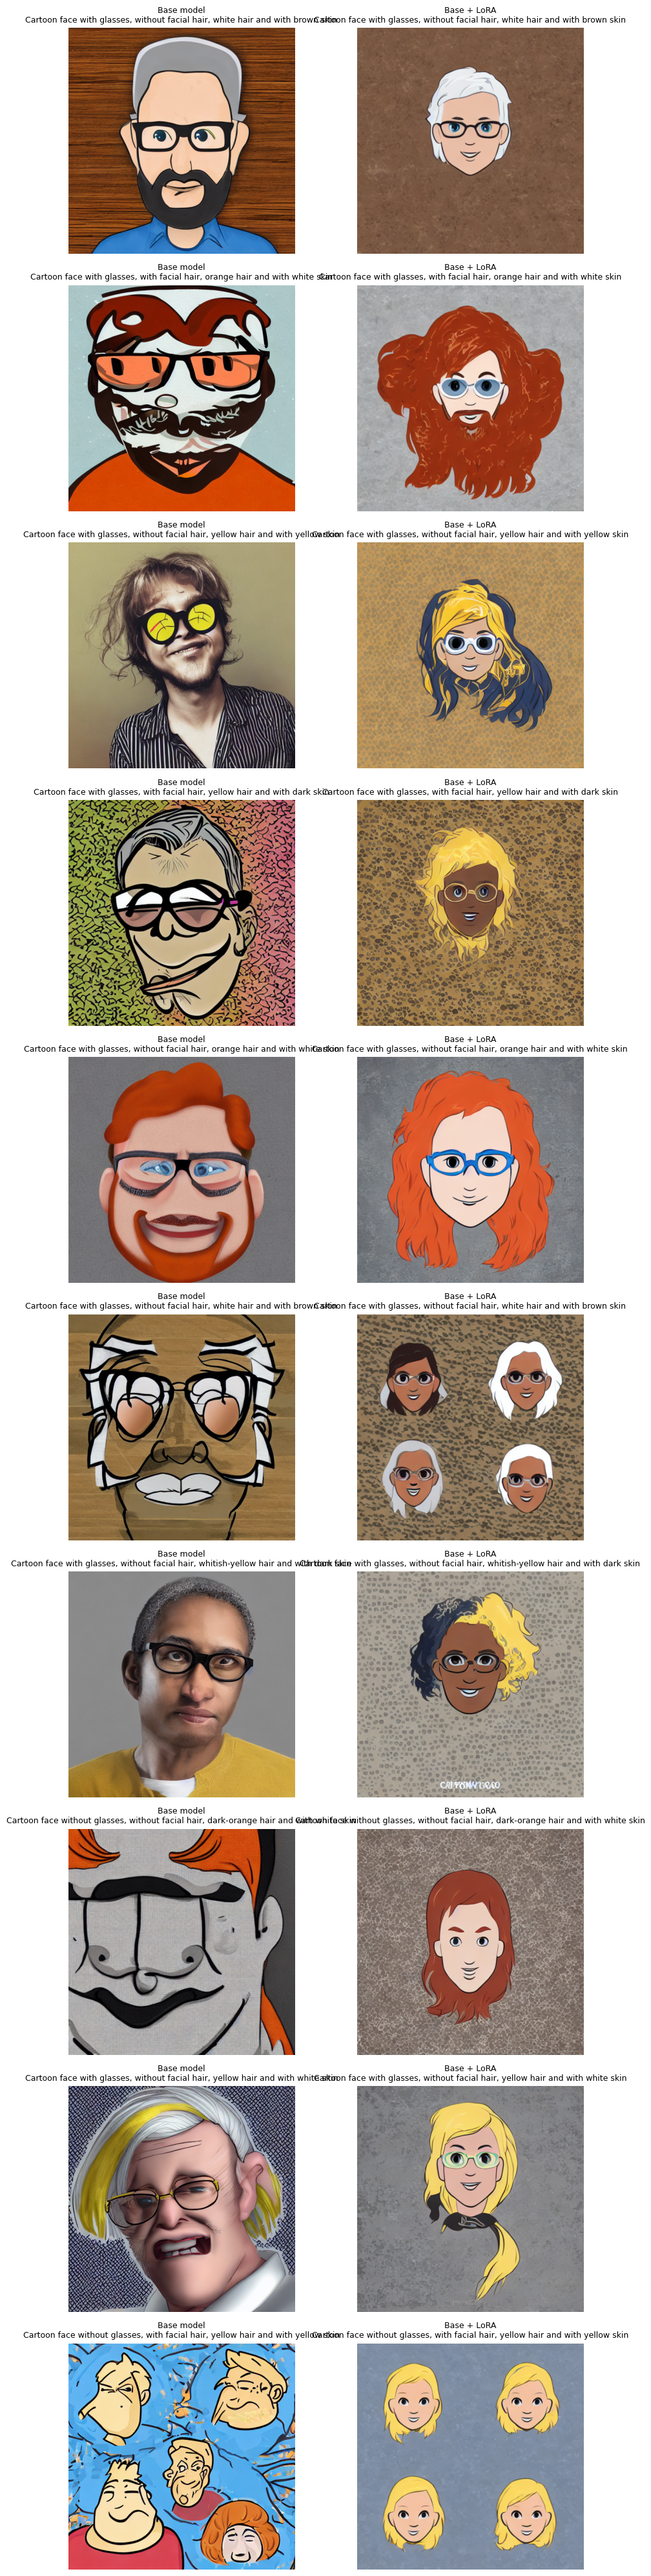

In [ ]:
INFERENCE_STEPS=20
GUIDANCE_SCALE=3.0
NUM_PROMPTS=10

@torch.no_grad()
def generate_images(pipe, prompts, base_seed=42):
    images = []
    for i, prompt in tqdm(enumerate(prompts), total=len(prompts)):
        generator = torch.Generator(device=DEVICE).manual_seed(base_seed + i)
        image = pipe(
            prompt,
            num_inference_steps=INFERENCE_STEPS,
            guidance_scale=GUIDANCE_SCALE,
            generator=generator,
        ).images[0]
        images.append(image)
    return images

base_images = generate_images(pipe_base, prompts, base_seed=SEED)
lora_images = generate_images(pipe_lora, prompts, base_seed=SEED)

fig, axes = plt.subplots(NUM_PROMPTS, 2, figsize=(10, 4 * NUM_PROMPTS))

if NUM_PROMPTS == 1:
    axes = [axes]

for i in range(NUM_PROMPTS):
    axes[i, 0].imshow(base_images[i])
    axes[i, 0].set_title(f"Base model\n{prompts[i]}", fontsize=9)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(lora_images[i])
    axes[i, 1].set_title(f"Base + LoRA\n{prompts[i]}", fontsize=9)
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
NUM_PROMPTS=100
indices = random.sample(range(len(hf_ds)), NUM_PROMPTS)

samples = [hf_ds[i] for i in indices]

prompts = [s["text"] for s in samples]
imgs = [s["image"] for s in samples]

OUT_BASE = Path("/content/eval/gen_base1")
OUT_LORA = Path("/content/eval/gen_lora1")
OUT_REAL = Path("/content/eval/original1")

OUT_BASE.mkdir(parents=True, exist_ok=True)
OUT_LORA.mkdir(parents=True, exist_ok=True)
OUT_REAL.mkdir(parents=True, exist_ok=True)

for i, img in enumerate(imgs):
    img = img.convert("RGB")
    img.save(OUT_REAL / f"{i:04d}.png")

for i, prompt in tqdm(enumerate(prompts), total=len(prompts)):

    for k in range(10):

        generator = torch.Generator(device=DEVICE).manual_seed(SEED + i + k)

        img_base = pipe_base(
            prompt=prompt,
            num_inference_steps=20,
            guidance_scale=4,
            generator=generator,
        ).images[0]

        img_base.save(OUT_BASE / f"{i:04d}_{k:04d}.png")

        img_lora = pipe_lora(
            prompt=prompt,
            num_inference_steps=20,
            guidance_scale=4,
            generator=generator,
        ).images[0]

        img_lora.save(OUT_LORA / f"{i:04d}_{k:04d}.png")



100%|██████████| 50/50 [13:41<00:00, 16.43s/it]


In [ ]:
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

base_prompt_scores = []
lora_prompt_scores = []

base_img_scores = []
lora_img_scores = []

base_scores_by_prompt = defaultdict(list)
lora_scores_by_prompt = defaultdict(list)

base_pair_sims = []
lora_pair_sims = []

for i in tqdm(range(NUM_PROMPTS)):

    real_img = Image.open(OUT_REAL / f"{i:04d}.png").convert("RGB")

    base_imgs = []
    lora_imgs = []

    for k in range(3):

        base_img = Image.open(OUT_BASE / f"{i:04d}_{k:04d}.png").convert("RGB")
        lora_img = Image.open(OUT_LORA / f"{i:04d}_{k:04d}.png").convert("RGB")

        base_imgs.append(base_img)
        lora_imgs.append(lora_img)

        prompt = prompts[i]

        inputs_base = clip_processor(text=[prompt], images=base_img, return_tensors="pt").to(DEVICE)
        inputs_lora = clip_processor(text=[prompt], images=lora_img, return_tensors="pt").to(DEVICE)

        with torch.no_grad():
            out_base = clip_model(**inputs_base)
            out_lora = clip_model(**inputs_lora)

        sb = out_base.logits_per_image.item()
        sl = out_lora.logits_per_image.item()

        base_prompt_scores.append(sb)
        lora_prompt_scores.append(sl)

        base_scores_by_prompt[i].append(sb)
        lora_scores_by_prompt[i].append(sl)

        base_img_scores.append(clip_image_similarity(real_img, base_img))
        lora_img_scores.append(clip_image_similarity(real_img, lora_img))

    base_sims = []
    lora_sims = []

    for a, b in itertools.combinations(base_imgs, 2):
        base_sims.append(clip_image_similarity(a, b))

    for a, b in itertools.combinations(lora_imgs, 2):
        lora_sims.append(clip_image_similarity(a, b))

    base_pair_sims.append(np.mean(base_sims))
    lora_pair_sims.append(np.mean(lora_sims))

print("Prompt similarity")
print("base:", np.mean(base_prompt_scores))
print("lora:", np.mean(lora_prompt_scores))

print()
print("Image similarity to original")
print("base:", np.mean(base_img_scores))
print("lora:", np.mean(lora_img_scores))

base_std = np.mean([np.std(v) for v in base_scores_by_prompt.values()])
lora_std = np.mean([np.std(v) for v in lora_scores_by_prompt.values()])

print()
print("CLIP std per prompt")
print("base:", base_std)
print("lora:", lora_std)

print()
print("Intra-prompt similarity (diversity)")
print("base:", np.mean(base_pair_sims))
print("lora:", np.mean(lora_pair_sims))

wins = sum(l > b for l, b in zip(lora_prompt_scores, base_prompt_scores))
total = len(base_prompt_scores)

print()
print("LoRA win rate:", wins / total)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 50/50 [00:18<00:00,  2.77it/s]

Prompt similarity
base: 31.779214719136554
lora: 31.94680236816406

Image similarity to original
base: 0.5133551738659541
lora: 0.6328973680734634

CLIP std per prompt
base: 1.8806628020289153
lora: 1.625907152285925

Intra-prompt similarity (diversity)
base: 0.5625811629494032
lora: 0.7598159046967824

LoRA win rate: 0.4866666666666667
